In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from plot_style import aplicar_estilo_graficos, COLOR_PRINCIPAL, PALETA_BASE

aplicar_estilo_graficos()

In [ ]:
path_segmentacion = "segmentacion_rfm.csv"
segmentacion = pd.read_csv(path_segmentacion)
segmentacion.head()

In [ ]:
segmentacion.columns
# Index(['Unnamed: 0', 'Cod Cliente', 'ticket_promedio', 'dias_entre_compras',
#        'recencia', 'ticket_promedio_nivel', 'frecuencia_nivel',
#        'recencia_nivel', 'segmento_umbrales_id', 'segmento_umbrales_desc'],
#       dtype='str')

In [ ]:
path_costos = "datos/ventas_costos_TRAD_final.xlsx"
lista_dfs_costos = []
xls = pd.ExcelFile(path_costos, engine="openpyxl")
for n, sheet_name in enumerate(xls.sheet_names):
    if n > 0:
        df = pd.read_excel(xls, sheet_name=sheet_name, engine="openpyxl", header=1)
        df["Mes"] = sheet_name  # Agregar columna con el nombre de la hoja (mes)
        lista_dfs_costos.append(df)
costos = pd.concat(lista_dfs_costos, ignore_index=True)
print("Costos - Filas:", costos.shape[0])
costos.head()

In [ ]:
costos["Mes"].unique()

In [ ]:
costos.columns
# Index(['Cod Cliente', 'Kilo Real', 'Monto Real', 'Aporte', 'Costo',
#        'Distribución Fijo', 'Frío Externo', 'T Producción',
#        'O. G. Fijos Indirectos', 'Gastos. Zonales Directos', 'Energía',
#        'Gastos DM Marketing', 'Reponer', 'Gastos DM Canales',
#        'Distribución Variable', 'Comisión FFVV', 'Gastos Comer. Directos',
#        'Cod Canal Comercial', 'Zona', 'Distrito', 'Dist. Aporte',
#        'Dist. Costo', 'Dist. Distribución Fijo', 'Dist. Frío Externo',
#        'Dist. T Producción', 'Dist. O. G. Fijos Indirectos',
#        'Dist. Gastos. Zonales Directos', 'Dist. Energía',
#        'Dist. Gastos DM Marketing', 'Dist. Reponer', 'Dist. Gastos DM Canales',
#        'Dist. Distribución Variable', 'Dist. Comisión FFVV',
#        'Dist. Gastos Comer. Directos', 'Margen Directo', 'Margen 1',
#        'Margen 2', 'EBITDA', 'Mes'],
#       dtype='str')

In [ ]:
path_info_zonales = "datos/Clientes - Zonales.xlsx"
zonales = pd.read_excel(path_info_zonales)
zonales.head()

In [ ]:
zonales.columns
# Index(['Id cliente', 'REGIONES'], dtype='str')

In [ ]:
zonales["REGIONES"].value_counts()

In [ ]:
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes = pd.read_excel(path_clientes, header=1)
clientes.head()

In [ ]:
clientes.columns
# Index(['Zona', 'Distrito', 'CodJV', 'CodSup', 'CodVend', 'NombreVendedor',
#        'Canal', 'SubCanal', 'CodCliente Padre', 'Cliente Padre', 'CodCliente',
#        'RazonSocial', 'Direccion', 'Comuna', 'TipoNeg', 'DesTipoNeg', 'Relev',
#        'NivPrecio', 'Telefono', 'Correo', 'VtaUlt3M', 'PromUlt3M',
#        'Margen3ULTM', 'PromMargen3ULTM', 'CodRuta', 'DesRuta', 'NroSec',
#        'RitmoVisita', 'LU', 'MA', 'MI', 'JU', 'VI', 'SA', 'Frecuencia',
#        'Tratamiento', 'CodPago', 'DesPago', 'Estado'],
#       dtype='str')

In [ ]:
margenes_cliente = costos.groupby("Cod Cliente").agg({
    "Kilo Real": "sum",
    "Monto Real": "sum",
    "Margen Directo": "sum",
    "Margen 1": "sum",
    "Margen 2": "sum",
    "EBITDA": "sum"
}).rename(columns={
    "Kilo Real": "Kilos",
    "Monto Real": "Ingresos"
}).reset_index()
margenes_cliente.head()

In [ ]:
def normalizar_llave_cliente(serie):
    valores_texto = serie.astype("string").str.strip()
    valores_numericos = pd.to_numeric(valores_texto, errors="coerce")
    valores_normalizados = valores_numericos.astype("Int64").astype("string")
    return valores_normalizados.fillna(valores_texto)


columnas_segmentacion = [
    "Cod Cliente",
    "ticket_promedio",
    "dias_entre_compras",
    "recencia",
    "ticket_promedio_nivel",
    "frecuencia_nivel",
    "recencia_nivel",
    "segmento_umbrales_id",
    "segmento_umbrales_desc",
]

segmentacion_clientes_info = (
    segmentacion[columnas_segmentacion]
    .drop_duplicates(subset="Cod Cliente")
    .copy()
)
segmentacion_clientes_info["llave_cliente_normalizada"] = normalizar_llave_cliente(
    segmentacion_clientes_info["Cod Cliente"]
)
segmentacion_clientes_info = segmentacion_clientes_info.drop(columns="Cod Cliente")

zonales_info = zonales[["Id cliente", "REGIONES"]].drop_duplicates(subset="Id cliente").copy()
zonales_info["llave_cliente_normalizada"] = normalizar_llave_cliente(zonales_info["Id cliente"])
zonales_info = zonales_info.drop(columns="Id cliente")

columnas_clientes = [
    "CodCliente",
    "TipoNeg",
    "DesTipoNeg",
    "Canal",
    "SubCanal",
    "Relev",
    "NivPrecio",
]
clientes_info = clientes[columnas_clientes].drop_duplicates(subset="CodCliente").copy()
clientes_info["llave_cliente_normalizada"] = normalizar_llave_cliente(clientes_info["CodCliente"])
clientes_info = clientes_info.drop(columns="CodCliente")

clientes_caracterizacion = margenes_cliente.copy()
clientes_caracterizacion["llave_cliente_normalizada"] = normalizar_llave_cliente(
    clientes_caracterizacion["Cod Cliente"]
)

clientes_caracterizacion = clientes_caracterizacion.merge(
    segmentacion_clientes_info,
    on="llave_cliente_normalizada",
    how="left",
).merge(
    zonales_info,
    on="llave_cliente_normalizada",
    how="left",
).merge(
    clientes_info,
    on="llave_cliente_normalizada",
    how="left",
)

for col in ["ticket_promedio_nivel", "frecuencia_nivel", "recencia_nivel"]:
    clientes_caracterizacion[col] = clientes_caracterizacion[col].fillna("sin_dato")

clientes_caracterizacion["segmento_umbrales_id"] = clientes_caracterizacion[
    "segmento_umbrales_id"
].fillna("Sin segmento")
clientes_caracterizacion["segmento_umbrales_desc"] = clientes_caracterizacion[
    "segmento_umbrales_desc"
].fillna("Sin segmento")
clientes_caracterizacion["segmento_ticket_frecuencia_desc"] = (
    "ticket_" + clientes_caracterizacion["ticket_promedio_nivel"].astype(str)
    + " | frecuencia_" + clientes_caracterizacion["frecuencia_nivel"].astype(str)
)

valores_sin_dato = {
    "REGIONES": "Sin zonal",
    "TipoNeg": "Sin tipo de negocio",
    "DesTipoNeg": "Sin tipo de negocio",
    "Canal": "Sin canal",
    "SubCanal": "Sin subcanal",
    "Relev": "Sin relevancia",
    "NivPrecio": "Sin nivel precio",
}
for col, valor_sin_dato in valores_sin_dato.items():
    clientes_caracterizacion[col] = (
        clientes_caracterizacion[col]
        .fillna(valor_sin_dato)
        .astype("string")
        .str.strip()
        .replace("", valor_sin_dato)
    )

clientes_caracterizacion = clientes_caracterizacion.drop(columns="llave_cliente_normalizada")

print("Clientes en tabla de caracterización:", clientes_caracterizacion.shape[0])
print("Cod Cliente único:", clientes_caracterizacion["Cod Cliente"].is_unique)
clientes_caracterizacion.head()

In [ ]:
clientes_caracterizacion_og = clientes_caracterizacion.copy()
clientes_caracterizacion = clientes_caracterizacion[
    (clientes_caracterizacion["Canal"] == "COBERTURA") &
    (clientes_caracterizacion["SubCanal"].isin(["COBERTURA", "VOLUMEN COBRETURA"])) &
    (~clientes_caracterizacion["segmento_ticket_frecuencia_desc"].isin(["ticket_sin_dato | frecuencia_sin_dato"]))
]

print("Clientes en tabla de caracterización:", clientes_caracterizacion.shape[0])

In [ ]:
clientes_caracterizacion["segmento_ticket_frecuencia_desc"].value_counts()

# Ingresos y margen según segmentación

In [ ]:
metricas_economicas = ["Ingresos", "Margen 2"] #, "EBITDA"]

clientes_segmentados_margenes = clientes_caracterizacion[
    ["Cod Cliente", "segmento_umbrales_desc"] + metricas_economicas
].copy()
clientes_segmentados_margenes["segmento_umbrales_desc"] = clientes_segmentados_margenes[
    "segmento_umbrales_desc"
].fillna("Sin segmento")
clientes_segmentados_margenes[metricas_economicas] = clientes_segmentados_margenes[
    metricas_economicas
].fillna(0)

resumen_segmentos_margenes = (
    clientes_segmentados_margenes
    .groupby("segmento_umbrales_desc", as_index=False)[metricas_economicas]
    .sum()
)

print("Clientes segmentados:", clientes_segmentados_margenes.shape[0])
print("Segmentos resumidos:", resumen_segmentos_margenes.shape[0])

In [ ]:
resumen_segmentos_margenes.sort_values("Ingresos", ascending=False)

In [ ]:
def formatear_millones(valor, _pos=None):
    signo = "-" if valor < 0 else ""
    return f"{signo}${abs(valor) / 1_000_000:,.1f} MM"


PALETA_METRICAS = {
    "Ingresos": PALETA_BASE[0],
    "Margen Directo": PALETA_BASE[1],
    "Margen 1": PALETA_BASE[2],
    "Margen 2": PALETA_BASE[3],
    "EBITDA": PALETA_BASE[4],
}


def formatear_etiqueta_segmento(segmento):
    partes = [parte.strip() for parte in str(segmento).split("|")]
    etiquetas = []
    for parte in partes:
        if parte.startswith("ticket_"):
            nivel = parte.replace("ticket_", "").replace("_", " ")
            etiquetas.append(f"Ticket {nivel}")
        elif parte.startswith("frecuencia_"):
            nivel = parte.replace("frecuencia_", "")
            nivel = {"alto": "alta", "medio": "media", "bajo": "baja"}.get(nivel, nivel)
            etiquetas.append(f"Frecuencia {nivel}")
        elif parte.startswith("recencia_"):
            nivel = parte.replace("recencia_", "").replace("_", " ")
            etiquetas.append(f"Recencia {nivel}")
        else:
            etiquetas.append(parte.replace("_", " ").title())
    return "\n".join(etiquetas)


def preparar_datos_grafico(df, categoria_col, orden_col):
    datos = df.sort_values(orden_col, ascending=False).copy()
    datos["etiqueta_x"] = datos[categoria_col].map(formatear_etiqueta_segmento)
    return datos


def graficar_metrica_vertical(df, categoria_col, metrica, titulo, etiqueta_x, color=None):
    datos = preparar_datos_grafico(df, categoria_col, metrica)
    fig, ax = plt.subplots(figsize=(max(18, len(datos) * 0.85), 8.5))

    sns.barplot(
        data=datos,
        x="etiqueta_x",
        y=metrica,
        color=color or PALETA_METRICAS.get(metrica, COLOR_PRINCIPAL),
        ax=ax,
    )

    ax.set_title(titulo)
    ax.set_xlabel(etiqueta_x)
    ax.set_ylabel("Monto total")
    ax.yaxis.set_major_formatter(FuncFormatter(formatear_millones))
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_axisbelow(True)

    max_abs = datos[metrica].abs().max()
    desplazamiento = max_abs * 0.015 if max_abs else 0

    for barra in ax.patches:
        altura = barra.get_height()
        x = barra.get_x() + barra.get_width() / 2
        etiqueta = formatear_millones(altura)
        if altura >= 0:
            ax.text(x, altura + desplazamiento, etiqueta, ha="center", va="bottom", fontsize=9)
        else:
            ax.text(x, altura - desplazamiento, etiqueta, ha="center", va="top", fontsize=9)

    if max_abs:
        minimo = datos[metrica].min()
        maximo = datos[metrica].max()
        if minimo >= 0:
            ax.set_ylim(0, maximo * 1.18)
        elif maximo <= 0:
            ax.set_ylim(minimo * 1.18, 0)
        else:
            ax.set_ylim(minimo * 1.05, maximo * 1.18)

    fig.tight_layout(rect=(0.02, 0.12, 0.98, 0.98))
    plt.show()


def graficar_metricas_combinadas(df, categoria_col, titulo, etiqueta_x, metricas=None):
    metricas = metricas or metricas_economicas
    datos = preparar_datos_grafico(df, categoria_col, "Ingresos")
    datos_largos = datos.melt(
        id_vars=[categoria_col, "etiqueta_x"],
        value_vars=metricas,
        var_name="metrica",
        value_name="monto",
    )

    fig, ax = plt.subplots(figsize=(max(20, len(datos) * 1.0), 9))

    sns.barplot(
        data=datos_largos,
        x="etiqueta_x",
        y="monto",
        hue="metrica",
        hue_order=metricas,
        palette=PALETA_METRICAS,
        ax=ax,
    )

    ax.set_title(titulo)
    ax.set_xlabel(etiqueta_x)
    ax.set_ylabel("Monto total")
    ax.yaxis.set_major_formatter(FuncFormatter(formatear_millones))
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_axisbelow(True)
    ax.legend(title="Métrica", ncols=3, loc="upper right") # , bbox_to_anchor=(0.5, 1.12)

    max_abs = datos_largos["monto"].abs().max()
    if max_abs:
        minimo = datos_largos["monto"].min()
        maximo = datos_largos["monto"].max()
        if minimo >= 0:
            ax.set_ylim(0, maximo * 1.12)
        elif maximo <= 0:
            ax.set_ylim(minimo * 1.12, 0)
        else:
            ax.set_ylim(minimo * 1.05, maximo * 1.12)

    fig.tight_layout(rect=(0.02, 0.12, 0.98, 0.95))
    plt.show()

In [ ]:
configuracion_graficos = [
    ("Ingresos", "Ingresos totales por segmento", PALETA_METRICAS["Ingresos"]),
    # ("Margen Directo", "Margen Directo total por segmento", PALETA_METRICAS["Margen Directo"]),
    # ("Margen 1", "Margen 1 total por segmento", PALETA_METRICAS["Margen 1"]),
    ("Margen 2", "Margen 2 total por segmento", PALETA_METRICAS["Margen 2"]),
    # ("EBITDA", "EBITDA total por segmento", PALETA_METRICAS["EBITDA"]),
]

for metrica, titulo, color in configuracion_graficos:
    graficar_metrica_vertical(
        resumen_segmentos_margenes,
        categoria_col="segmento_umbrales_desc",
        metrica=metrica,
        titulo=titulo,
        etiqueta_x="Segmento RFM",
        color=color,
    )

graficar_metricas_combinadas(
    resumen_segmentos_margenes,
    categoria_col="segmento_umbrales_desc",
    titulo="Ingresos y márgenes por segmento",
    etiqueta_x="Segmento RFM",
)

In [ ]:
clientes_segmentados_sin_recencia_margenes = clientes_caracterizacion[
    ["Cod Cliente", "segmento_ticket_frecuencia_desc"] + metricas_economicas
].copy()
clientes_segmentados_sin_recencia_margenes["segmento_ticket_frecuencia_desc"] = (
    clientes_segmentados_sin_recencia_margenes["segmento_ticket_frecuencia_desc"]
    .fillna("ticket_sin_dato | frecuencia_sin_dato")
)
clientes_segmentados_sin_recencia_margenes[metricas_economicas] = (
    clientes_segmentados_sin_recencia_margenes[metricas_economicas]
    .fillna(0)
)

resumen_segmentos_sin_recencia_margenes = (
    clientes_segmentados_sin_recencia_margenes
    .groupby("segmento_ticket_frecuencia_desc", as_index=False)[metricas_economicas]
    .sum()
)

print("Grupos ticket/frecuencia:", resumen_segmentos_sin_recencia_margenes.shape[0])
resumen_segmentos_sin_recencia_margenes.sort_values("Ingresos", ascending=False)

configuracion_graficos_sin_recencia = [
    ("Ingresos", "Ingresos totales por ticket y frecuencia", PALETA_METRICAS["Ingresos"]),
    # ("Margen Directo", "Margen Directo total por ticket y frecuencia", PALETA_METRICAS["Margen Directo"]),
    # ("Margen 1", "Margen 1 total por ticket y frecuencia", PALETA_METRICAS["Margen 1"]),
    ("Margen 2", "Margen 2 total por ticket y frecuencia", PALETA_METRICAS["Margen 2"]),
    # ("EBITDA", "EBITDA total por ticket y frecuencia", PALETA_METRICAS["EBITDA"]),
]

for metrica, titulo, color in configuracion_graficos_sin_recencia:
    graficar_metrica_vertical(
        resumen_segmentos_sin_recencia_margenes,
        categoria_col="segmento_ticket_frecuencia_desc",
        metrica=metrica,
        titulo=titulo,
        etiqueta_x="Segmento",
        color=color,
    )

graficar_metricas_combinadas(
    resumen_segmentos_sin_recencia_margenes,
    categoria_col="segmento_ticket_frecuencia_desc",
    titulo="Ingresos y márgenes por ticket y frecuencia",
    etiqueta_x="Segmento",
)

In [ ]:
margenes_cliente = costos.groupby("Cod Cliente").agg({
    "Kilo Real": "sum",
    "Monto Real": "sum",
    "Margen Directo": "sum",
    "Margen 1": "sum",
    "Margen 2": "sum",
    "EBITDA": "sum"
}).rename(columns={
    "Kilo Real": "Kilos",
    "Monto Real": "Ingresos"
}).reset_index()
margenes_cliente.head()

# Ingresos y margen según zonal

In [ ]:
clientes_caracterizacion["REGIONES"].value_counts()

In [ ]:
metricas_agrupacion_clientes = ["Ingresos", "Margen 2"] #, "EBITDA"]


def preparar_resumen_clientes_por_categoria(
    clientes_df,
    categoria_col,
    categoria_sin_dato,
    cliente_col="Cod Cliente",
    metricas=None,
):
    metricas = metricas or metricas_agrupacion_clientes
    columnas_requeridas = [cliente_col, categoria_col] + metricas
    faltantes = [col for col in columnas_requeridas if col not in clientes_df.columns]
    if faltantes:
        raise ValueError(f"Columnas no encontradas en clientes_df: {', '.join(faltantes)}")

    clientes_categoria_margenes = clientes_df[columnas_requeridas].copy()
    clientes_categoria_margenes[categoria_col] = (
        clientes_categoria_margenes[categoria_col]
        .fillna(categoria_sin_dato)
        .astype("string")
        .str.strip()
        .replace("", categoria_sin_dato)
    )
    clientes_categoria_margenes[metricas] = clientes_categoria_margenes[metricas].fillna(0)

    resumen_categoria_margenes = (
        clientes_categoria_margenes
        .groupby(categoria_col, as_index=False)[metricas]
        .sum()
        .sort_values("Ingresos", ascending=False)
    )

    return clientes_categoria_margenes, resumen_categoria_margenes


In [ ]:
clientes_zonal_margenes, resumen_zonal_margenes = preparar_resumen_clientes_por_categoria(
    clientes_caracterizacion,
    categoria_col="REGIONES",
    categoria_sin_dato="Sin zonal",
)

print("Clientes con zonal:", clientes_zonal_margenes.shape[0])
print("Zonales resumidos:", resumen_zonal_margenes.shape[0])

for metrica in metricas_agrupacion_clientes:
    graficar_metrica_vertical(
        resumen_zonal_margenes,
        categoria_col="REGIONES",
        metrica=metrica,
        titulo=f"{metrica} total por zonal",
        etiqueta_x="Zonal",
        color=PALETA_METRICAS[metrica],
    )

graficar_metricas_combinadas(
    resumen_zonal_margenes,
    categoria_col="REGIONES",
    titulo="Ingresos, Margen 2 y EBITDA por zonal",
    etiqueta_x="Zonal",
    metricas=metricas_agrupacion_clientes,
)

In [ ]:
bajada_zonales = resumen_zonal_margenes.copy()
bajada_zonales["Margen 2 %"] = bajada_zonales["Margen 2"] / bajada_zonales["Ingresos"]

# TO DO: Sacar población
poblacion_comunas = {
    "SANTIAGO": 438856,
    "VIÑA DEL MAR": 334871,
    "SAN FERNANDO": 75585,
    "LA SERENA": 250141,
    "CONCEPCION": 230375,
    "TEMUCO": 292518,
    "CHILLAN": 190382,
    "RANCAGUA": 257744,
    "ANTOFAGASTA": 401096,
    "TALCA": 232131,
    "IQUIQUE": 199587,
    "LOS ANGELES": 219441,
    "OSORNO": 166455,
    "COPIAPO": 168831,
    "SAN FELIPE": 80413,
    "CALAMA": 166334,
    "ARICA": 241653,
    "PUERTO MONTT": 277040,
    "PUNTA ARENAS": 132363,
    "COYHAYQUE": 57823,  # Coyhaique
}
bajada_zonales["Poblacion"] = bajada_zonales["REGIONES"].map(poblacion_comunas)

bajada_zonales["Ingresos/Población"] =  bajada_zonales["Ingresos"] / bajada_zonales["Poblacion"]

bajada_zonales.sort_values("Ingresos", ascending=False).transpose().to_excel("bajada_zonales.xlsx")

In [ ]:
bajada_zonales

# Ingresos y margen según tipo de negocio

In [ ]:
clientes_caracterizacion["DesTipoNeg"].value_counts()

In [ ]:
clientes_tipo_negocio_margenes, resumen_tipo_negocio_margenes = preparar_resumen_clientes_por_categoria(
    clientes_caracterizacion,
    categoria_col="DesTipoNeg",
    categoria_sin_dato="Sin tipo de negocio",
)

print("Clientes con tipo de negocio:", clientes_tipo_negocio_margenes.shape[0])
print("Tipos de negocio resumidos:", resumen_tipo_negocio_margenes.shape[0])

for metrica in metricas_agrupacion_clientes:
    graficar_metrica_vertical(
        resumen_tipo_negocio_margenes,
        categoria_col="DesTipoNeg",
        metrica=metrica,
        titulo=f"{metrica} total por tipo de negocio",
        etiqueta_x="Tipo de negocio",
        color=PALETA_METRICAS[metrica],
    )

graficar_metricas_combinadas(
    resumen_tipo_negocio_margenes,
    categoria_col="DesTipoNeg",
    titulo="Ingresos, Margen 2 y EBITDA por tipo de negocio",
    etiqueta_x="Tipo de negocio",
    metricas=metricas_agrupacion_clientes,
)

In [ ]:
# Tabla bajada de gráfico
bajada_tipo_neg = resumen_tipo_negocio_margenes.copy()
bajada_tipo_neg["Margen 2 %"] = bajada_tipo_neg["Margen 2"] / bajada_tipo_neg["Ingresos"]

bajada_tipo_neg["NumClientes"] = bajada_tipo_neg["DesTipoNeg"].map(clientes_caracterizacion["DesTipoNeg"].value_counts())

bajada_tipo_neg["Ingresos/NumClientes"] =  bajada_tipo_neg["Ingresos"] / bajada_tipo_neg["NumClientes"]

bajada_tipo_neg.sort_values("Ingresos", ascending=False).transpose().to_excel("bajada_tipo_neg.xlsx")

In [ ]:
path_seg_comp_compra = "segmentacion_clientes_comp_compra.csv"
segm_comp_compra = pd.read_csv(path_seg_comp_compra)
segm_comp_compra.head()

In [ ]:
segm_comp_compra.columns
# Index(['Unnamed: 0', 'Cod Cliente', 'n_facturas', 'ticket_promedio',
#        'cv_ticket', 'recencia', 'skus_distintos', 'share_marca_LA PREFERIDA',
#        'share_marca_SAN JORGE', 'share_familia_MORTADELAS',
#        'share_familia_VIENESAS', 'share_familia_QUESOS',
#        'share_familia_JAMON G1', 'share_familia_JAMON G2',
#        'share_familia_PARRILLEROS', 'hhi_familias', 'share_empaque_GRANEL',
#        'cluster', 'nombre_cluster'],
#       dtype='str')

In [ ]:
mapeo_cliente_clsuter = dict(zip(segm_comp_compra['Cod Cliente'], segm_comp_compra['cluster']))

clientes_caracterizacion["cluster"] = clientes_caracterizacion["Cod Cliente"].map(mapeo_cliente_clsuter)

In [ ]:
clientes_segm_comp_compra_margenes, resumen_segm_comp_compra_margenes = preparar_resumen_clientes_por_categoria(
    clientes_caracterizacion,
    categoria_col="cluster",
    categoria_sin_dato="Sin tipo de negocio",
)

print("Clientes con tipo de negocio:", clientes_segm_comp_compra_margenes.shape[0])
print("Tipos de negocio resumidos:", resumen_segm_comp_compra_margenes.shape[0])

for metrica in metricas_agrupacion_clientes:
    graficar_metrica_vertical(
        resumen_segm_comp_compra_margenes,
        categoria_col="cluster",
        metrica=metrica,
        titulo=f"{metrica} total por cluster",
        etiqueta_x="Cluster",
        color=PALETA_METRICAS[metrica],
    )

graficar_metricas_combinadas(
    resumen_segm_comp_compra_margenes,
    categoria_col="cluster",
    titulo="Ingresos, Margen 2 y EBITDA por cluster",
    etiqueta_x="Cluster",
    metricas=metricas_agrupacion_clientes,
)

In [ ]:
# Dividir por cantidad de clientes

metricas_cluster_per_cliente = ["Ingresos", "Margen 2", "EBITDA"]

def formatear_cluster(valor):
    if pd.isna(valor):
        return "Sin cluster"

    valor_num = pd.to_numeric(pd.Series([valor]), errors="coerce").iloc[0]
    if pd.notna(valor_num):
        if float(valor_num).is_integer():
            return f"Cluster {int(valor_num)}"
        return f"Cluster {valor_num:g}"

    return str(valor)


datos_cluster_per_cliente = clientes_caracterizacion.copy()
datos_cluster_per_cliente["cluster_label"] = datos_cluster_per_cliente["cluster"].map(formatear_cluster)

agregaciones_cluster = {
    "NumClientes": ("Cod Cliente", "nunique"),
}
for metrica in metricas_cluster_per_cliente:
    agregaciones_cluster[metrica] = (metrica, "sum")

resumen_cluster_per_cliente = (
    datos_cluster_per_cliente
    .groupby("cluster_label", as_index=False, sort=False)
    .agg(**agregaciones_cluster)
)

for metrica in metricas_cluster_per_cliente:
    resumen_cluster_per_cliente[f"{metrica}/cliente"] = (
        resumen_cluster_per_cliente[metrica] / resumen_cluster_per_cliente["NumClientes"]
    )

resumen_cluster_per_cliente = resumen_cluster_per_cliente.sort_values(
    "Ingresos/cliente",
    ascending=False,
)

resumen_cluster_per_cliente["etiqueta_x"] = resumen_cluster_per_cliente.apply(
    lambda fila: f"{fila['cluster_label']}\n({int(fila['NumClientes']):,} clientes)",
    axis=1,
)

datos_grafico_cluster_per_cliente = resumen_cluster_per_cliente.melt(
    id_vars=["cluster_label", "etiqueta_x", "NumClientes"],
    value_vars=[f"{metrica}/cliente" for metrica in metricas_cluster_per_cliente],
    var_name="metrica",
    value_name="monto_por_cliente",
)

datos_grafico_cluster_per_cliente["metrica_base"] = (
    datos_grafico_cluster_per_cliente["metrica"].str.replace("/cliente", "", regex=False)
)

fig, ax = plt.subplots(figsize=(max(16, len(resumen_cluster_per_cliente) * 1.2), 8.5))

sns.barplot(
    data=datos_grafico_cluster_per_cliente,
    x="etiqueta_x",
    y="monto_por_cliente",
    hue="metrica_base",
    hue_order=metricas_cluster_per_cliente,
    palette=PALETA_METRICAS,
    ax=ax,
)

ax.set_title("Ingresos, Margen 2 y EBITDA por cliente promedio de cada cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Monto por cliente")
ax.yaxis.set_major_formatter(FuncFormatter(formatear_millones))
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_axisbelow(True)
ax.legend(title="Métrica", ncols=3, loc="upper right")

max_abs = datos_grafico_cluster_per_cliente["monto_por_cliente"].abs().max()
if max_abs:
    minimo = datos_grafico_cluster_per_cliente["monto_por_cliente"].min()
    maximo = datos_grafico_cluster_per_cliente["monto_por_cliente"].max()
    if minimo >= 0:
        ax.set_ylim(0, maximo * 1.15)
    elif maximo <= 0:
        ax.set_ylim(minimo * 1.15, 0)
    else:
        ax.set_ylim(minimo * 1.05, maximo * 1.15)

fig.tight_layout(rect=(0.02, 0.08, 0.98, 0.95))
plt.show()

resumen_cluster_per_cliente

In [ ]:
resumen_cluster_per_cliente.to_excel("tabla_clusters_cool.xlsx")

In [ ]:
# Ver intersección con tipo de negocio

def preparar_tablas_interseccion_clientes(
    df,
    categoria_col,
    categoria_sin_dato,
    cluster_col="cluster",
    cliente_col="Cod Cliente",
    decimales=1,
):
    datos = df[[cliente_col, cluster_col, categoria_col]].copy()

    datos["cluster_label"] = datos[cluster_col].map(formatear_cluster)
    datos[categoria_col] = (
        datos[categoria_col]
        .fillna(categoria_sin_dato)
        .astype("string")
        .str.strip()
        .replace("", categoria_sin_dato)
    )

    datos = datos.drop_duplicates(subset=cliente_col)

    conteo = pd.crosstab(
        datos["cluster_label"],
        datos[categoria_col],
    )

    orden_clusters = (
        datos[["cluster_label", cluster_col]]
        .drop_duplicates()
        .assign(
            cluster_orden=lambda x: pd.to_numeric(x[cluster_col], errors="coerce").fillna(999_999)
        )
        .sort_values(["cluster_orden", "cluster_label"])
        ["cluster_label"]
        .tolist()
    )

    orden_categorias = conteo.sum(axis=0).sort_values(ascending=False).index.tolist()

    conteo = conteo.reindex(
        index=orden_clusters,
        columns=orden_categorias,
        fill_value=0,
    )

    tabla_pct_cluster = (
        conteo
        .div(conteo.sum(axis=1).where(lambda x: x.ne(0)), axis=0)
        .mul(100)
        .round(decimales)
        .fillna(0)
    )

    tabla_pct_categoria = (
        conteo.T
        .div(conteo.sum(axis=0).where(lambda x: x.ne(0)), axis=0)
        .mul(100)
        .round(decimales)
        .fillna(0)
    )

    return tabla_pct_cluster, tabla_pct_categoria, conteo


tabla_cluster_tipo_negocio_pct, tabla_tipo_negocio_cluster_pct, conteo_cluster_tipo_negocio = (
    preparar_tablas_interseccion_clientes(
        clientes_caracterizacion,
        categoria_col="DesTipoNeg",
        categoria_sin_dato="Sin tipo de negocio",
    )
)

display(
    tabla_cluster_tipo_negocio_pct
    .style
    .format("{:.1f}%")
    .set_caption("% de cada cluster que corresponde a cada tipo de negocio")
)

display(
    tabla_tipo_negocio_cluster_pct
    .style
    .format("{:.1f}%")
    .set_caption("% de cada tipo de negocio que pertenece a cada cluster")
)

In [ ]:
# Ver interesección con relevancia

tabla_cluster_relevancia_pct, tabla_relevancia_cluster_pct, conteo_cluster_relevancia = (
    preparar_tablas_interseccion_clientes(
        clientes_caracterizacion,
        categoria_col="Relev",
        categoria_sin_dato="Sin relevancia",
    )
)

display(
    tabla_cluster_relevancia_pct
    .style
    .format("{:.1f}%")
    .set_caption("% de cada cluster que corresponde a cada relevancia")
)

display(
    tabla_relevancia_cluster_pct
    .style
    .format("{:.1f}%")
    .set_caption("% de cada relevancia que pertenece a cada cluster")
)

# Pareto por cliente

In [ ]:
def preparar_datos_pareto_cliente(
    df,
    metrica='Clientes',
    cliente_col='Cod Cliente',
    top_n=None,
    solo_positivos=True,
):
    columnas_requeridas = [cliente_col, metrica]
    faltantes = [col for col in columnas_requeridas if col not in df.columns]
    if faltantes:
        raise ValueError(f'Columnas no encontradas: {", ".join(faltantes)}')

    if top_n is not None:
        top_n = int(top_n)
        if top_n <= 0:
            raise ValueError('top_n debe ser None o un entero positivo.')

    datos = df[[cliente_col, metrica]].dropna(subset=[metrica]).copy()
    if solo_positivos:
        datos = datos[datos[metrica] > 0]

    datos = datos.sort_values(metrica, ascending=False).reset_index(drop=True)
    if datos.empty:
        raise ValueError(f'No hay clientes con datos validos para {metrica}.')

    total_base = datos[metrica].sum()
    if total_base == 0:
        raise ValueError(f'El total base de {metrica} es cero; no se puede calcular Pareto.')

    datos['ranking_cliente'] = datos.index + 1
    datos['acumulado'] = datos[metrica].cumsum()
    datos['acumulado_pct'] = datos['acumulado'] / total_base * 100
    total_clientes_base = len(datos)

    if top_n is not None:
        datos = datos.head(top_n).copy()

    return datos, total_base, total_clientes_base


def graficar_pareto_cliente(
    df,
    metrica='Clientes',
    cliente_col='Cod Cliente',
    top_n=None,
    solo_positivos=True,
    umbral_pct=80,
    max_etiquetas_cliente=40,
    color_barra=None,
    color_linea=None,
    figsize=None,
    titulo=None,
    etiqueta_x=None,
):
    datos, total_base, total_clientes_base = preparar_datos_pareto_cliente(
        df,
        metrica=metrica,
        cliente_col=cliente_col,
        top_n=top_n,
        solo_positivos=solo_positivos,
    )

    if figsize is None:
        ancho = 18 if top_n is None else max(14, min(24, len(datos) * 0.09))
        figsize = (ancho, 8.5)

    color_barra = color_barra or PALETA_METRICAS.get(metrica, COLOR_PRINCIPAL)
    color_linea = color_linea or PALETA_BASE[1]
    color_referencia = PALETA_BASE[5]

    fig, ax = plt.subplots(figsize=figsize)
    ax2 = ax.twinx()

    barras = ax.bar(
        datos['ranking_cliente'],
        datos[metrica],
        color=color_barra,
        width=1.0 if len(datos) > 200 else 0.8,
        alpha=0.9,
        label=metrica,
    )
    linea, = ax2.plot(
        datos['ranking_cliente'],
        datos['acumulado_pct'],
        color=color_linea,
        linewidth=2.5,
        label='% acumulado',
    )

    referencia = ax2.axhline(
        umbral_pct,
        color=color_referencia,
        linestyle='--',
        linewidth=1.2,
        alpha=0.8,
        label=f'Referencia {umbral_pct:.0f}%',
    )

    cruce_umbral = datos.loc[datos['acumulado_pct'] >= umbral_pct]
    if not cruce_umbral.empty:
        punto_umbral = cruce_umbral.iloc[0]
        ranking_umbral = int(punto_umbral['ranking_cliente'])
        ax.axvline(
            ranking_umbral,
            color=color_referencia,
            linestyle=':',
            linewidth=1.2,
            alpha=0.8,
        )
        ax2.scatter(
            [ranking_umbral],
            [punto_umbral['acumulado_pct']],
            color=color_linea,
            s=42,
            zorder=5,
        )
        ax2.annotate(
            f'{umbral_pct:.0f}% en cliente #{ranking_umbral:,}',
            xy=(ranking_umbral, umbral_pct),
            xytext=(10, 12),
            textcoords='offset points',
            color=COLOR_PRINCIPAL,
            fontsize=10,
        )

    titulo_top = '' if top_n is None else f' - Top {len(datos):,}'
    titulo_filtro = ' positivos' if solo_positivos else ''
    titulo = titulo or f'Pareto de {metrica} por cliente{titulo_top}'
    etiqueta_x = etiqueta_x or f'Clientes{titulo_filtro} ordenados por {metrica} (ranking)'
    ax.set_title(titulo)
    ax.set_xlabel(etiqueta_x)
    ax.set_ylabel(metrica)
    ax2.set_ylabel('% acumulado')

    ax.yaxis.set_major_formatter(FuncFormatter(formatear_millones))
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda valor, _pos: f'{valor:.0f}%'))

    if len(datos) <= max_etiquetas_cliente:
        ax.set_xticks(datos['ranking_cliente'])
        ax.set_xticklabels(datos[cliente_col].astype(str), rotation=90, ha='center')
    else:
        ax.locator_params(axis='x', nbins=12, integer=True)

    ax.set_xlim(0.5, datos['ranking_cliente'].max() + 0.5)
    ax2.set_ylim(0, 105)
    ax.set_axisbelow(True)
    ax.grid(axis='y')
    ax2.grid(False)

    maximo = datos[metrica].max()
    if maximo > 0:
        ax.set_ylim(0, maximo * 1.15)

    total_formateado = formatear_millones(total_base)
    clientes_texto = f'{len(datos):,}'
    if top_n is not None and len(datos) < total_clientes_base:
        clientes_texto = f'{len(datos):,} de {total_clientes_base:,}'
    ax.text(
        0.01,
        0.96,
        f'Total base: {total_formateado} | Clientes: {clientes_texto}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        color=COLOR_PRINCIPAL,
    )

    ax.legend(
        [barras, linea, referencia],
        [metrica, '% acumulado', f'Referencia {umbral_pct:.0f}%'],
        loc='upper right',
    )

    fig.tight_layout(rect=(0.02, 0.06, 0.98, 0.98))
    plt.show()


In [ ]:
for metrica in ['Ingresos', 'Margen 2', 'EBITDA']:
    graficar_pareto_cliente(
        clientes_caracterizacion,
        metrica=metrica,
        top_n=None,
        solo_positivos=True,
    )

# Scatter de clientes

In [ ]:
def formatear_porcentaje(valor, _pos=None):
    return f'{valor:.0%}'


def preparar_datos_scatter_clientes(
    margenes_df,
    segmentacion_df=None,
    cliente_col='Cod Cliente',
    margen_col='EBITDA',
):
    columnas_margenes = [cliente_col, 'Ingresos', margen_col]
    faltantes_margenes = [col for col in columnas_margenes if col not in margenes_df.columns]
    if faltantes_margenes:
        raise ValueError(f'Columnas no encontradas en margenes_df: {", ".join(faltantes_margenes)}')

    columnas_segmentacion = [
        cliente_col,
        'ticket_promedio_nivel',
        'frecuencia_nivel',
        'recencia_nivel',
        'segmento_umbrales_desc',
    ]
    columnas_extra = [col for col in ['Kilos'] if col in margenes_df.columns]

    if segmentacion_df is None:
        faltantes_segmentacion = [col for col in columnas_segmentacion if col not in margenes_df.columns]
        if faltantes_segmentacion:
            raise ValueError(
                'Si no entregas segmentacion_df, margenes_df debe incluir: '
                + ', '.join(faltantes_segmentacion)
            )
        columnas_datos = columnas_margenes + columnas_extra + [
            col for col in columnas_segmentacion if col not in columnas_margenes + columnas_extra
        ]
        datos = margenes_df[columnas_datos].copy()
    else:
        faltantes_segmentacion = [col for col in columnas_segmentacion if col not in segmentacion_df.columns]
        if faltantes_segmentacion:
            raise ValueError(
                f'Columnas no encontradas en segmentacion_df: {", ".join(faltantes_segmentacion)}'
            )
        datos_margenes = margenes_df[columnas_margenes + columnas_extra].copy()
        datos_segmentacion = (
            segmentacion_df[columnas_segmentacion]
            .drop_duplicates(subset=cliente_col)
            .copy()
        )
        datos = datos_margenes.merge(datos_segmentacion, on=cliente_col, how='left')
    datos = datos[datos['Ingresos'] > 0].copy()
    if datos.empty:
        raise ValueError('No hay clientes con Ingresos > 0 para graficar en escala logaritmica.')

    for col in ['ticket_promedio_nivel', 'frecuencia_nivel', 'recencia_nivel']:
        datos[col] = datos[col].fillna('sin_dato')
    datos['segmento_umbrales_desc'] = datos['segmento_umbrales_desc'].fillna('sin_segmento')
    datos['segmento_fm_desc'] = (
        'ticket_' + datos['ticket_promedio_nivel'].astype(str)
        + ' | frecuencia_' + datos['frecuencia_nivel'].astype(str)
    )
    datos['margen_pct'] = datos[margen_col] / datos['Ingresos']
    return datos


def ordenar_categorias_scatter(categorias, color_por):
    orden_nivel = {'alto': 0, 'medio': 1, 'bajo': 2, 'sin_dato': 99}
    orden_recencia = {'reciente': 0, 'intermedia': 1, 'antigua': 2, 'sin_dato': 99}

    def extraer_nivel(segmento, prefijo):
        for parte in str(segmento).split('|'):
            parte = parte.strip()
            if parte.startswith(f'{prefijo}_'):
                return parte.replace(f'{prefijo}_', '')
        return 'sin_dato'

    if color_por == 'recencia':
        return sorted(categorias, key=lambda cat: orden_recencia.get(str(cat), 98))
    if color_por in ['rfm', 'fm']:
        return sorted(
            categorias,
            key=lambda cat: (
                orden_nivel.get(extraer_nivel(cat, 'ticket'), 98),
                orden_nivel.get(extraer_nivel(cat, 'frecuencia'), 98),
                orden_recencia.get(extraer_nivel(cat, 'recencia'), 98),
                str(cat),
            ),
        )
    return sorted(categorias)


def etiqueta_categoria_scatter(categoria, color_por):
    if color_por == 'recencia':
        return f'Recencia {str(categoria).replace("_", " ")}'
    if categoria == 'sin_segmento':
        return 'Sin segmento'
    return formatear_etiqueta_segmento(categoria).replace('\n', ' | ')


def construir_paleta_scatter(categorias, color_por):
    if color_por == 'rfm':
        colores = sns.color_palette('husl', n_colors=len(categorias)).as_hex()
    else:
        colores = PALETA_BASE
        if len(categorias) > len(colores):
            colores = sns.color_palette('tab10', n_colors=len(categorias)).as_hex()
    return {categoria: colores[i % len(colores)] for i, categoria in enumerate(categorias)}


def calcular_tamano_puntos(datos, size_col='Ingresos', min_size=12, max_size=220):
    if size_col is None:
        return pd.Series((min_size + max_size) / 2, index=datos.index)
    if size_col not in datos.columns:
        raise ValueError(f'Columna de tamano no encontrada: {size_col}')

    valores = datos[size_col]
    if pd.api.types.is_numeric_dtype(valores):
        valores = valores.fillna(0).clip(lower=0) ** 0.5
        minimo = valores.min()
        maximo = valores.max()
        if maximo == minimo:
            return pd.Series((min_size + max_size) / 2, index=datos.index)
        return min_size + (valores - minimo) / (maximo - minimo) * (max_size - min_size)

    mapa_tamano = {'bajo': min_size, 'medio': (min_size + max_size) / 2, 'alto': max_size}
    return valores.map(mapa_tamano).fillna((min_size + max_size) / 2)


def dibujar_scatter_clientes(ax, datos, categorias, color_col, paleta, alpha=0.32):
    for categoria in categorias:
        datos_categoria = datos[datos[color_col] == categoria]
        if datos_categoria.empty:
            continue
        ax.scatter(
            datos_categoria['Ingresos'],
            datos_categoria['margen_pct'],
            s=datos_categoria['tamano_punto'],
            color=paleta[categoria],
            alpha=alpha,
            edgecolors='none',
            rasterized=True,
        )


def configurar_ejes_scatter_clientes(ax, margen_col, escala_x_log=True, limite_y=None):
    if escala_x_log:
        ax.set_xscale('log')
    ax.axhline(0, color=PALETA_BASE[5], linestyle='--', linewidth=1.1, alpha=0.75)
    ax.set_xlabel('Ingresos')
    ax.set_ylabel(f'{margen_col} / Ingresos')
    ax.xaxis.set_major_formatter(FuncFormatter(formatear_millones))
    ax.yaxis.set_major_formatter(FuncFormatter(formatear_porcentaje))
    ax.tick_params(axis='both', labelsize=10)
    ax.set_axisbelow(True)
    if limite_y is not None:
        ax.set_ylim(limite_y)


def agregar_leyenda_scatter(ax, categorias, paleta, color_por, titulo_color, ncols=None):
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker='o',
            color='white',
            markerfacecolor=paleta[categoria],
            markersize=7,
            label=etiqueta_categoria_scatter(categoria, color_por),
        )
        for categoria in categorias
    ]
    if ncols is None:
        ncols = 2 if len(categorias) > 12 else 1
    ax.legend(
        handles=handles,
        title=titulo_color,
        loc='upper left',
        bbox_to_anchor=(1.01, 1),
        ncols=ncols,
        fontsize=8 if len(categorias) > 12 else 9,
        title_fontsize=10,
    )


def graficar_scatter_clientes(
    margenes_df,
    segmentacion_df=None,
    margen_col='EBITDA',
    color_por='rfm',
    size_col='Ingresos',
    facet_recencia=False,
    escala_x_log=True,
    limite_y=None,
    figsize=None,
):
    config_color = {
        'rfm': ('segmento_umbrales_desc', 'Segmento RFM'),
        'fm': ('segmento_fm_desc', 'Segmento FM'),
        'recencia': ('recencia_nivel', 'Recencia'),
    }
    if color_por not in config_color:
        raise ValueError("color_por debe ser 'rfm', 'fm' o 'recencia'.")

    datos = preparar_datos_scatter_clientes(
        margenes_df,
        segmentacion_df,
        margen_col=margen_col,
    )
    color_col, titulo_color = config_color[color_por]
    datos[color_col] = datos[color_col].fillna('sin_segmento')
    datos['tamano_punto'] = calcular_tamano_puntos(datos, size_col=size_col)

    categorias = ordenar_categorias_scatter(datos[color_col].dropna().unique().tolist(), color_por)
    paleta = construir_paleta_scatter(categorias, color_por)
    titulo_base = f'Ingresos vs. {margen_col} porcentual por cliente'
    subtitulo = f'Color: {titulo_color} | Tamano: {size_col or "fijo"} | Clientes: {len(datos):,}'

    if facet_recencia:
        orden_recencia = ['reciente', 'intermedia', 'antigua', 'sin_dato']
        recencias = [rec for rec in orden_recencia if rec in datos['recencia_nivel'].unique()]
        if not recencias:
            raise ValueError('No hay valores de recencia_nivel para separar en paneles.')
        if figsize is None:
            figsize = (max(18, len(recencias) * 6.2), 7.2)
        fig, axes = plt.subplots(1, len(recencias), figsize=figsize, sharex=True, sharey=True)
        if len(recencias) == 1:
            axes = [axes]
        for ax, recencia in zip(axes, recencias):
            datos_panel = datos[datos['recencia_nivel'] == recencia]
            dibujar_scatter_clientes(ax, datos_panel, categorias, color_col, paleta)
            configurar_ejes_scatter_clientes(ax, margen_col, escala_x_log, limite_y)
            ax.set_title(f'Recencia {recencia} | Clientes: {len(datos_panel):,}', fontsize=13)
        fig.suptitle(f'{titulo_base}\n{subtitulo}', x=0.02, ha='left', fontsize=18, fontweight='bold')
        agregar_leyenda_scatter(axes[-1], categorias, paleta, color_por, titulo_color)
        fig.tight_layout(rect=(0.02, 0.03, 0.84, 0.9))
        plt.show()
        return

    if figsize is None:
        figsize = (15, 8.5)
    fig, ax = plt.subplots(figsize=figsize)
    dibujar_scatter_clientes(ax, datos, categorias, color_col, paleta)
    configurar_ejes_scatter_clientes(ax, margen_col, escala_x_log, limite_y)
    ax.set_title(f'{titulo_base}\n{subtitulo}')
    agregar_leyenda_scatter(ax, categorias, paleta, color_por, titulo_color)
    fig.tight_layout(rect=(0.02, 0.03, 0.82, 0.98))
    plt.show()


In [ ]:
graficar_scatter_clientes(
    clientes_caracterizacion,
    color_por='rfm',
    size_col='Ingresos',
    facet_recencia=False,
)

graficar_scatter_clientes(
    clientes_caracterizacion,
    color_por='fm',
    size_col='Ingresos',
    facet_recencia=False,
)

graficar_scatter_clientes(
    clientes_caracterizacion,
    color_por='fm',
    size_col='Ingresos',
    facet_recencia=True,
)

# Heatmap de ticket promedio x frecuencia

In [ ]:
def preparar_matriz_heatmap_ticket_frecuencia(
    margenes_df,
    segmentacion_df=None,
    metrica='Clientes',
    cliente_col='Cod Cliente',
    ticket_col='ticket_promedio_nivel',
    frecuencia_col='frecuencia_nivel',
    orden_niveles=('bajo', 'medio', 'alto'),
):
    columnas_segmentacion = [cliente_col, ticket_col, frecuencia_col]

    if segmentacion_df is None:
        columnas_base = columnas_segmentacion.copy()
        if metrica != 'Clientes':
            columnas_base.append(metrica)
        faltantes = [col for col in columnas_base if col not in margenes_df.columns]
        if faltantes:
            raise ValueError(
                'Si no entregas segmentacion_df, margenes_df debe incluir: '
                + ', '.join(faltantes)
            )
        datos = margenes_df[columnas_base].copy()
    else:
        faltantes_segmentacion = [col for col in columnas_segmentacion if col not in segmentacion_df.columns]
        if faltantes_segmentacion:
            raise ValueError(
                f'Columnas no encontradas en segmentacion_df: {", ".join(faltantes_segmentacion)}'
            )
        datos = (
            segmentacion_df[columnas_segmentacion]
            .drop_duplicates(subset=cliente_col)
            .copy()
        )
        if metrica != 'Clientes':
            columnas_margenes = [cliente_col, metrica]
            faltantes_margenes = [col for col in columnas_margenes if col not in margenes_df.columns]
            if faltantes_margenes:
                raise ValueError(
                    f'Columnas no encontradas en margenes_df: {", ".join(faltantes_margenes)}'
                )
            datos = datos.merge(margenes_df[columnas_margenes], on=cliente_col, how='left')

    if metrica == 'Clientes':
        datos_agrupados = (
            datos
            .groupby([ticket_col, frecuencia_col])[cliente_col]
            .nunique()
            .reset_index(name=metrica)
        )
    else:
        datos[metrica] = datos[metrica].fillna(0)
        datos_agrupados = (
            datos
            .groupby([ticket_col, frecuencia_col], as_index=False)[metrica]
            .sum()
        )

    matriz = datos_agrupados.pivot(
        index=ticket_col,
        columns=frecuencia_col,
        values=metrica,
    )
    matriz = matriz.reindex(index=orden_niveles, columns=orden_niveles).fillna(0)
    return matriz


def formatear_anotaciones_heatmap(matriz, metrica):
    if metrica == 'Clientes':
        return matriz.apply(lambda col: col.map(lambda valor: f'{int(valor):,}'))
    return matriz.apply(lambda col: col.map(lambda valor: formatear_millones(valor)))


def configurar_escala_heatmap(matriz, metrica):
    minimo = matriz.min().min()
    maximo = matriz.max().max()

    if metrica == 'Clientes':
        return {
            'cmap': sns.light_palette(PALETA_BASE[1], as_cmap=True),
            'vmin': 0,
            'vmax': maximo if maximo > 0 else 1,
            'center': None,
            'cbar_kws': {'label': 'Cantidad de clientes'},
        }

    if minimo < 0:
        limite = max(abs(minimo), abs(maximo))
        limite = limite if limite > 0 else 1
        return {
            'cmap': sns.diverging_palette(10, 220, as_cmap=True),
            'vmin': -limite,
            'vmax': limite,
            'center': 0,
            'cbar_kws': {'label': 'Monto total'},
        }

    color_base = PALETA_METRICAS.get(metrica, COLOR_PRINCIPAL)
    return {
        'cmap': sns.light_palette(color_base, as_cmap=True),
        'vmin': 0,
        'vmax': maximo if maximo > 0 else 1,
        'center': None,
        'cbar_kws': {'label': 'Monto total'},
    }


def titulo_heatmap_ticket_frecuencia(metrica):
    if metrica == 'Clientes':
        return 'Cantidad de clientes'
    return f'{metrica} total'


def graficar_heatmaps_ticket_frecuencia(
    margenes_df,
    segmentacion_df=None,
    metricas=('Clientes', 'Ingresos', 'Margen 2', 'EBITDA'),
    cliente_col='Cod Cliente',
    figsize=(16, 12),
    ncols=2,
):
    metricas = list(metricas)
    if not metricas:
        raise ValueError('Debes entregar al menos una metrica para graficar.')
    if ncols <= 0:
        raise ValueError('ncols debe ser un entero positivo.')

    nrows = (len(metricas) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)

    etiquetas_niveles = ['Bajo', 'Medio', 'Alto']
    for ax, metrica in zip(axes.flat, metricas):
        matriz = preparar_matriz_heatmap_ticket_frecuencia(
            margenes_df,
            segmentacion_df,
            metrica=metrica,
            cliente_col=cliente_col,
        )
        anotaciones = formatear_anotaciones_heatmap(matriz, metrica)
        escala = configurar_escala_heatmap(matriz, metrica)

        sns.heatmap(
            matriz,
            annot=anotaciones,
            fmt='',
            cmap=escala['cmap'],
            vmin=escala['vmin'],
            vmax=escala['vmax'],
            center=escala['center'],
            linewidths=0.8,
            linecolor='white',
            cbar_kws=escala['cbar_kws'],
            ax=ax,
        )
        ax.set_title(titulo_heatmap_ticket_frecuencia(metrica))
        ax.set_xlabel('Frecuencia')
        ax.set_ylabel('Ticket promedio')
        ax.set_xticklabels(etiquetas_niveles, rotation=0)
        ax.set_yticklabels(etiquetas_niveles, rotation=0)
        ax.invert_yaxis()
        ax.tick_params(axis='both', labelsize=10)

    for ax in axes.flat[len(metricas):]:
        ax.axis('off')

    fig.suptitle(
        'Heatmap ticket promedio x frecuencia',
        x=0.02,
        ha='left',
        fontsize=18,
        fontweight='bold',
        color=COLOR_PRINCIPAL,
    )
    fig.tight_layout(rect=(0.02, 0.03, 0.98, 0.95))
    plt.show()


In [ ]:
graficar_heatmaps_ticket_frecuencia(
    clientes_caracterizacion,
    metricas=('Clientes', 'Ingresos', 'Margen 2', 'EBITDA'),
)

# Heatmaps de clientes según segmentación

In [253]:
path_seg_fm = "segmentacion_fm_vs_desarrollables.csv"
seg_fm = pd.read_csv(path_seg_fm)
seg_fm.head()

,Cod Cliente,ticket_promedio,ticket_promedio_nivel,dias_entre_compras,frecuencia_compras,frecuencia_nivel,segmento_fm_id,segmento_fm_desc,segmento_fm_agrupado
0,1199536,26595.681818,bajo,17.500000,0.057143,medio,S02,ticket_bajo | frecuencia_medio,Esforzado
1,1178409,110381.368421,alto,10.937500,0.091429,medio,S08,ticket_alto | frecuencia_medio,Desarrollable
2,1096778,279896.318182,alto,8.333333,0.120000,alto,S09,ticket_alto | frecuencia_alto,VIP
3,1151218,87506.550000,alto,10.937500,0.091429,medio,S08,ticket_alto | frecuencia_medio,Desarrollable
4,1000127,30117.555556,bajo,21.875000,0.045714,bajo,S01,ticket_bajo | frecuencia_bajo,Pequeños


In [254]:
path_seg_canasta = "segmentacion_clientes_canasta.csv"
seg_canasta = pd.read_csv(path_seg_canasta)
seg_canasta.head()

,Cod Cliente,cluster,cluster_agrupado
0,235,6,Charcutería colonial/salchichón
1,499,6,Charcutería colonial/salchichón
2,547,3,Queso gauda + básicos
3,665,2,Mortadelas + básicos
4,1012,5,Salame chico / comida rápida


In [257]:
import textwrap

def graficar_heatmaps_canasta_fm(
    margenes_df,
    seg_canasta,
    seg_fm,
    metricas=("Clientes", "Ingresos", "Margen 2", "EBITDA"),
    cliente_col="Cod Cliente",
    cluster_col="cluster_agrupado",
    fm_col="segmento_fm_agrupado",
    max_label_width=18,
):
    def ordenar_valores(valores):
        try:
            return sorted(valores, key=lambda x: float(x))
        except Exception:
            return sorted(valores)

    def envolver_label(label, width=max_label_width):
        label = str(label).replace("Canasta ", "").replace("canasta ", "")
        return "\n".join(textwrap.wrap(label, width=width))

    def formatear_valor(valor, metrica):
        if metrica == "Clientes":
            return f"{int(valor):,}"

        valor_abs = abs(valor)

        # if valor_abs >= 1_000_000_000:
        #     return f"{valor / 1_000_000_000:.1f}"
        if valor_abs >= 1_000_000:
            return f"{valor / 1_000_000:.0f}"
        elif valor_abs >= 1_000:
            return f"{valor / 1_000:.0f}K"
        else:
            return f"{valor:.0f}"

    datos = (
        seg_canasta[[cliente_col, cluster_col]]
        .drop_duplicates(subset=cliente_col)
        .merge(
            seg_fm[[cliente_col, fm_col]].drop_duplicates(subset=cliente_col),
            on=cliente_col,
            how="inner",
        )
        .merge(
            margenes_df[[cliente_col] + [m for m in metricas if m != "Clientes"]],
            on=cliente_col,
            how="left",
        )
    )

    orden_clusters = ordenar_valores(datos[cluster_col].dropna().unique())
    orden_fm_deseado = [
        "VIP",
        "Desarrollable",
        "Fidelizados",
        "Neutro",
        "Oportunista",
        "Esforzado",
        "Pequeños",
    ]

    valores_fm = datos[fm_col].dropna().unique()

    orden_fm = (
        [seg for seg in orden_fm_deseado if seg in valores_fm]
        + [seg for seg in ordenar_valores(valores_fm) if seg not in orden_fm_deseado]
    )

    for metrica in metricas:

        if metrica == "Clientes":
            datos_agrupados = (
                datos
                .groupby([fm_col, cluster_col])[cliente_col]
                .nunique()
                .reset_index(name=metrica)
            )
        else:
            datos[metrica] = datos[metrica].fillna(0)
            datos_agrupados = (
                datos
                .groupby([fm_col, cluster_col], as_index=False)[metrica]
                .sum()
            )

        matriz = (
            datos_agrupados
            .pivot(index=fm_col, columns=cluster_col, values=metrica)
            .reindex(index=orden_fm, columns=orden_clusters)
            .fillna(0)
        )

        anotaciones = matriz.map(lambda x: formatear_valor(x, metrica))

        figsize = (
            # max(10, 1.35 * len(matriz.columns)),
            # max(4.75, 0.4 * len(matriz.index) + 2),
            8,6
        )
        print(f"figsize={figsize}")

        plt.figure(figsize=figsize)

        ax = sns.heatmap(
            matriz,
            annot=anotaciones,
            fmt="",
            cmap="Blues" if metrica != "Clientes" else "BuGn",
            linewidths=0.8,
            linecolor="white",
            cbar=False,
            # cbar_kws={
            #     "shrink": 0.8,
            #     "label": "Cantidad de clientes" if metrica == "Clientes" else "Monto total",
            #     "orientation": "horizontal"
            # },
            annot_kws={
                "fontsize": 13,
                "fontweight": "bold",
            },
        )

        titulo = "Cantidad de clientes" if metrica == "Clientes" else f"{metrica} total"

        ax.set_title(
            titulo,
            fontsize=18,
            fontweight="bold",
            color=COLOR_PRINCIPAL,
            pad=16,
        )

        ax.set_xlabel("", fontsize=12, fontweight="bold")
        ax.set_ylabel("", fontsize=12, fontweight="bold")

        ax.set_xticklabels(
            [envolver_label(label.get_text()) for label in ax.get_xticklabels()],
            rotation=50,
            ha="right",
            fontsize=9,
        )

        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0,
            fontsize=10,
        )

        plt.tight_layout()
        plt.show()

figsize=(8, 6)


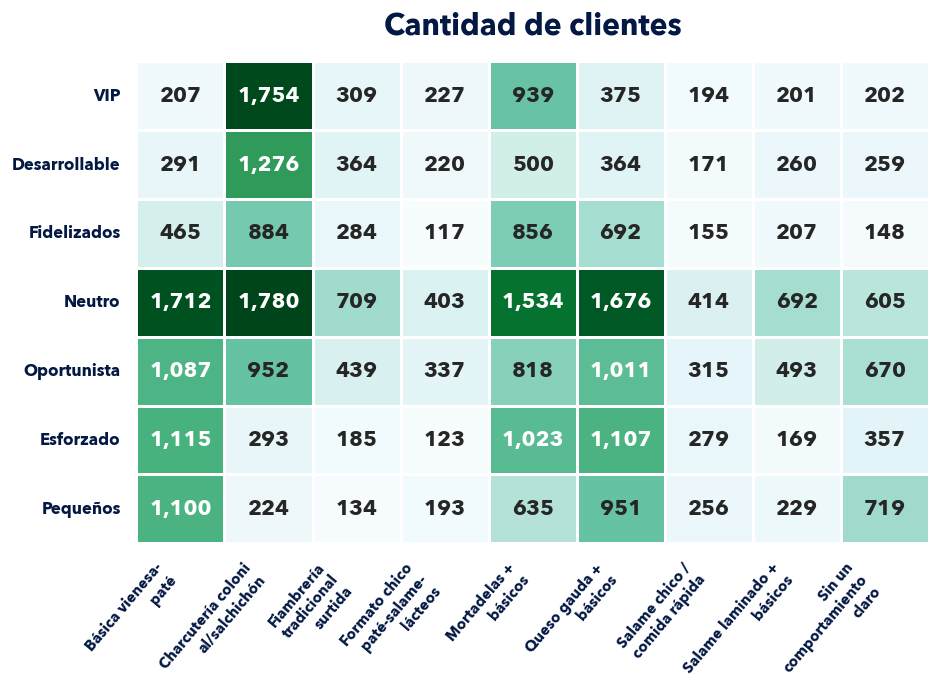

figsize=(8, 6)


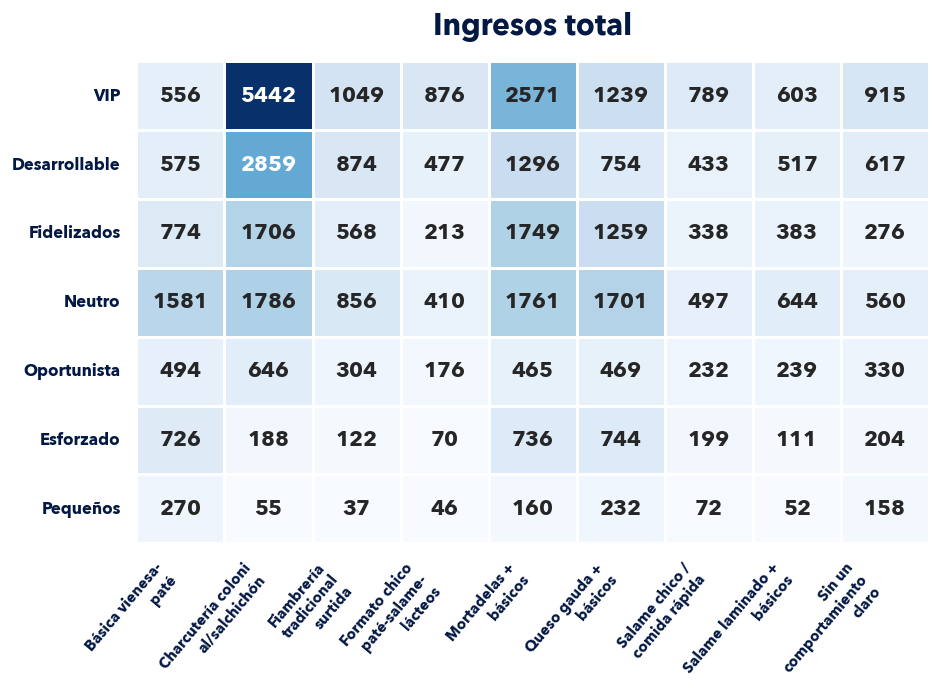

figsize=(8, 6)


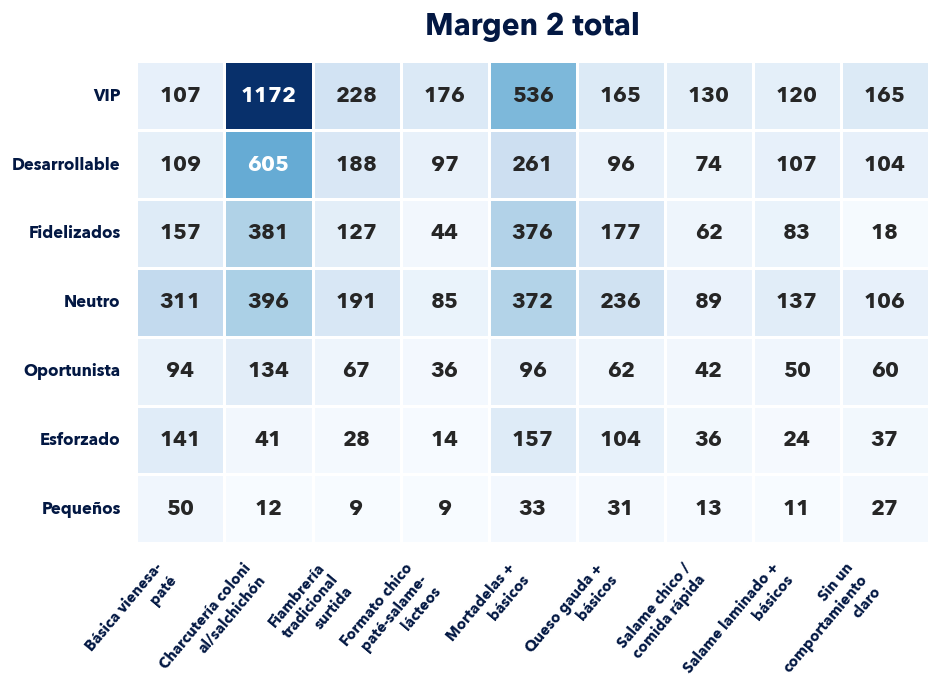

figsize=(8, 6)


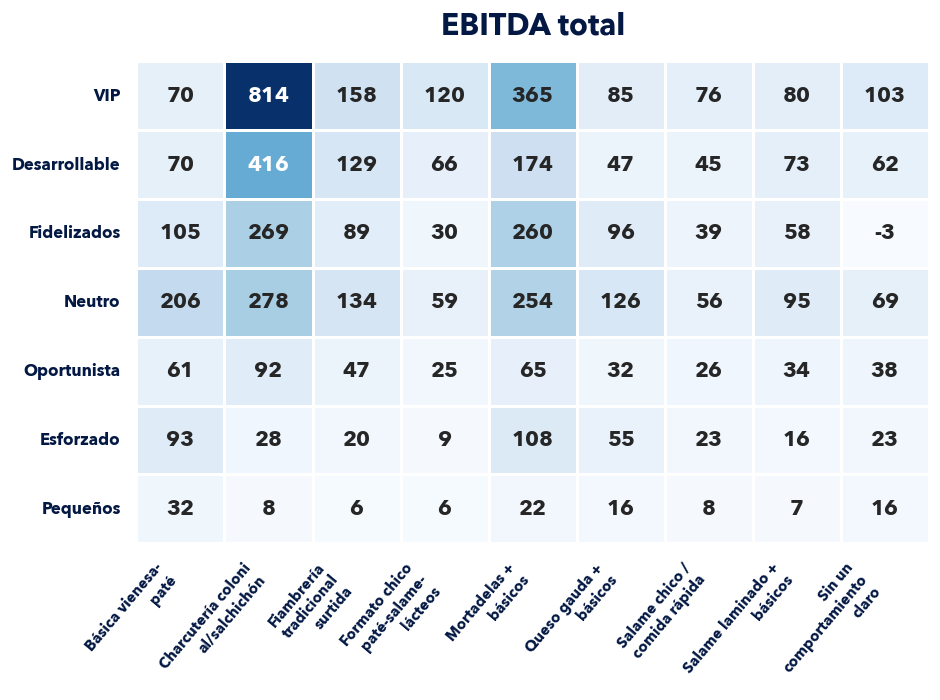

In [258]:
graficar_heatmaps_canasta_fm(
    clientes_caracterizacion,
    seg_canasta,
    seg_fm,
    metricas=("Clientes", "Ingresos", "Margen 2", "EBITDA"),
)

In [ ]:
clientes_vip = clientes_caracterizacion[
    clientes_caracterizacion["segmento_ticket_frecuencia_desc"] == "ticket_alto | frecuencia_alto"
]

clientes_vip.head()

In [ ]:
def graficar_pareto_clientes_vip(
    df,
    metrica,
    cliente_col='Cod Cliente',
    solo_positivos=True,
    umbral_pct=80,
    buffer_clientes=20,
    color_barra=None,
    color_linea=None,
):
    datos, total_base, total_clientes_base = preparar_datos_pareto_cliente(
        df,
        metrica=metrica,
        cliente_col=cliente_col,
        top_n=None,
        solo_positivos=solo_positivos,
    )

    cruce_umbral = datos.loc[datos['acumulado_pct'] >= umbral_pct]
    if cruce_umbral.empty:
        raise ValueError(f'No se pudo encontrar el cruce de {umbral_pct}% para {metrica}.')

    punto_umbral = cruce_umbral.iloc[0]
    ranking_umbral = int(punto_umbral['ranking_cliente'])
    buffer_clientes = max(5, int(buffer_clientes))
    ultimo_visible = min(total_clientes_base, ranking_umbral + buffer_clientes)
    datos_visibles = datos[datos['ranking_cliente'] <= ultimo_visible].copy()

    color_barra = color_barra or PALETA_METRICAS.get(metrica, COLOR_PRINCIPAL)
    color_linea = color_linea or PALETA_BASE[1]
    color_referencia = PALETA_BASE[5]

    ancho = max(14, min(22, len(datos_visibles) * 0.12))
    fig, ax = plt.subplots(figsize=(ancho, 8.5))
    ax2 = ax.twinx()

    barras = ax.bar(
        datos_visibles['ranking_cliente'],
        datos_visibles[metrica],
        color=color_barra,
        width=0.85,
        alpha=0.9,
        label=metrica,
    )
    linea, = ax2.plot(
        datos_visibles['ranking_cliente'],
        datos_visibles['acumulado_pct'],
        color=color_linea,
        linewidth=2.5,
        label='% acumulado',
    )

    referencia = ax2.axhline(
        umbral_pct,
        color=color_referencia,
        linestyle='--',
        linewidth=1.2,
        alpha=0.8,
        label=f'Referencia {umbral_pct:.0f}%',
    )
    ax.axvline(
        ranking_umbral,
        color=color_referencia,
        linestyle=':',
        linewidth=1.2,
        alpha=0.85,
    )
    ax2.scatter(
        [ranking_umbral],
        [punto_umbral['acumulado_pct']],
        color=color_linea,
        s=42,
        zorder=5,
    )
    ax2.annotate(
        f'{umbral_pct:.0f}% en cliente #{ranking_umbral:,}',
        xy=(ranking_umbral, punto_umbral['acumulado_pct']),
        xytext=(10, 12),
        textcoords='offset points',
        color=COLOR_PRINCIPAL,
        fontsize=10,
    )

    participacion_clientes = ranking_umbral / total_clientes_base if total_clientes_base else 0
    titulo = f'Pareto de {metrica} dentro de clientes VIP'
    subtitulo = (
        f'{umbral_pct:.0f}% de {metrica} se concentra en {ranking_umbral:,} clientes VIP '
        f'({participacion_clientes:.1%} del segmento)'
    )
    ax.set_title(f'{titulo}\n{subtitulo}')
    ax.set_xlabel(f'Clientes VIP positivos ordenados por {metrica} (ranking)')
    ax.set_ylabel(metrica)
    ax2.set_ylabel('% acumulado')

    ax.yaxis.set_major_formatter(FuncFormatter(formatear_millones))
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda valor, _pos: f'{valor:.0f}%'))
    ax.locator_params(axis='x', nbins=12, integer=True)

    ax.set_xlim(0.5, ultimo_visible + 0.5)
    ax2.set_ylim(0, 105)
    ax.set_axisbelow(True)
    ax.grid(axis='y')
    ax2.grid(False)

    maximo = datos_visibles[metrica].max()
    if maximo > 0:
        ax.set_ylim(0, maximo * 1.15)

    ax.text(
        0.01,
        0.96,
        (
            f'Total base: {formatear_millones(total_base)} | '
            f'Clientes VIP positivos: {total_clientes_base:,} | '
            f'Muestra visible: {len(datos_visibles):,}'
        ),
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        color=COLOR_PRINCIPAL,
    )

    ax.legend(
        [barras, linea, referencia],
        [metrica, '% acumulado', f'Referencia {umbral_pct:.0f}%'],
        loc='upper right',
    )

    fig.tight_layout(rect=(0.02, 0.06, 0.98, 0.98))
    plt.show()


print(f'Clientes VIP: {len(clientes_vip):,}')

for metrica in ['Ingresos', 'Margen 2', 'EBITDA']:
    graficar_pareto_clientes_vip(
        clientes_vip,
        metrica=metrica,
        solo_positivos=True,
        umbral_pct=80,
        buffer_clientes=20,
    )